# Analyzing data from Task 1 

Note to self: trying to run `cmdstanpy` on windows is quite painful ... let's try to keep the workflow mostly in MacOS ... 

In [1]:
import polars as pl
import arviz as az
import arviz_plots as azp
import os 
import shutil 
from cmdstanpy import CmdStanModel
from cmdstanpy import cmdstan_path
print(f'cmdstan is installed at {cmdstan_path()}')

cmdstan is installed at /Users/shenglong/.cmdstan/cmdstan-2.38.0


In [2]:
from utils import pp_check_dens_overlay, pp_check_pit_ecdf, pp_check_ecdf_overlay

In [3]:
# read in data 
task1_df = pl.read_csv("../../data/processed/task1.csv")
task1_df.head()

,participantId,task,id,rsp_time,status,data.select.x,data.select.y,pixel.select.x,pixel.select.y,param.mu,param.sigma,param.lambda,param.p,param.q,pixelToMM,dist_to_screen,data.select.left_area,data.ans.x,pixel.med.x,pixel.mod.x,phy.select.x,phy.med.x,phy.mod.x,va.select.x,va.med.x,va.mod.x
i64,str,str,i64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,"""67f03733938aa3f0d17ce8a8""","""task1""",1,8.22,"""completed""",0.34,0.218606,335.69,323.650744,0.41,1.5,-0.01,3.69,16.55,4.6,668.258963,"""0.489697578893479""",0.387128,338.211338,339.435,62.106522,62.654639,62.920652,5.321116,5.368009,5.390766
2,"""67f03733938aa3f0d17ce8a8""","""task1""",2,5.467,"""completed""",0.09,0.310524,322.315,287.34312,-0.65,1.17,0.53,2.92,5.89,4.6,668.258963,"""0.4692395323358""",0.189605,327.643861,282.725,59.198913,60.357361,50.592391,5.072333,5.171459,4.335665
3,"""67f03733938aa3f0d17ce8a8""","""task1""",3,5.354,"""completed""",0.34,0.521065,335.69,204.179468,0.42,0.62,-0.15,3.94,37.73,4.6,668.258963,"""0.53331408923348""",0.276061,332.26924,339.97,62.106522,61.362878,63.036957,5.321116,5.257493,5.400716
4,"""67f03733938aa3f0d17ce8a8""","""task1""",4,5.059,"""completed""",0.09,0.350077,322.315,271.719768,-0.89,1.05,0.79,2.6,27.22,4.6,668.258963,"""0.467448266910563""",0.183909,327.339129,269.885,59.198913,60.291115,47.801087,5.072333,5.165791,4.096666
5,"""67f03733938aa3f0d17ce8a8""","""task1""",5,5.606,"""completed""",-0.43,0.634068,294.495,159.543153,-0.37,0.51,-0.15,3.91,46.15,4.6,668.258963,"""0.536955412831699""",-0.488288,291.376613,297.705,53.151087,52.473177,53.848913,4.554715,4.496682,4.61445


Get the data ready for stan: 

In [4]:
numeric_id = task1_df.select(pl.col('participantId').cast(pl.Categorical).to_physical()).to_numpy().flatten()
# make sure the ids are not 0-indexed 
numeric_id += 1 

stan_data = {
    'N': task1_df.height, 
    'J': task1_df.select(pl.col('participantId')).n_unique(), 
    'id': numeric_id, 
    'x': task1_df.select('va.select.x').to_numpy().flatten(), 
    'x_med': task1_df.select('va.med.x').to_numpy().flatten(),
    'x_mod': task1_df.select('va.mod.x').to_numpy().flatten()
}

# stan_data

# Compile stan models 

## `task1.weighted.avg.stan` 

- centered parameterization 

Mathematical model as follows: 

... 

In [5]:
task1_mix_stanfile = os.path.join('../stan_files/', "task1.weighted.avg.stan")
task1_model = CmdStanModel(stan_file=task1_mix_stanfile)

22:19:01 - cmdstanpy - INFO - compiling stan file /Users/shenglong/Downloads/vis-decode-analysis/analysis/stan_files/task1.weighted.avg.stan to exe file /Users/shenglong/Downloads/vis-decode-analysis/analysis/stan_files/task1.weighted.avg
22:19:06 - cmdstanpy - INFO - compiled model executable: /Users/shenglong/Downloads/vis-decode-analysis/analysis/stan_files/task1.weighted.avg


In [6]:
# use shutil to move things around
dest_dir = "../stan_bin_files"
shutil.move(task1_model.exe_file, os.path.join(dest_dir, task1_model.name))
task1_model = CmdStanModel(exe_file=os.path.join(dest_dir, task1_model.name))

In [7]:
# sample 
fit1 = task1_model.sample(
    data = stan_data, 
    chains=4, 
    parallel_chains=4, 
    iter_warmup=4000,
    iter_sampling=4000,
    adapt_delta=0.99, 
    show_console=True, 
)

21:18:55 - cmdstanpy - INFO - Chain [1] start processing
21:18:55 - cmdstanpy - INFO - Chain [2] start processing
21:18:55 - cmdstanpy - INFO - Chain [3] start processing
21:18:55 - cmdstanpy - INFO - Chain [4] start processing


Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 4000
Chain [1] num_warmup = 4000
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.99
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 10 (Default)
Chain [1] metric = diag_e (Default)
Chain [1] metric_file =  (Default)
Chain [1] stepsize = 1 (Default)
Chain [1] stepsize_jitter = 0 (Default)
Chain [1] num_chains = 1 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /var/folders/xz/hg6l5mzj2wnb8mr2q4slgnr40000gn/T/tmp70jkojoc/1vkxutw3.json
Chain [1] init = 2 (Default)
Chain [1] random
Chain [1] seed

21:19:17 - cmdstanpy - INFO - Chain [4] done processing


Chain [1] Iteration: 7000 / 8000 [ 87%]  (Sampling)
Chain [4] Iteration: 8000 / 8000 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 12.558 seconds (Warm-up)
Chain [4] 9.326 seconds (Sampling)
Chain [4] 21.884 seconds (Total)
Chain [4] 
Chain [4] 
Chain [3] Iteration: 7100 / 8000 [ 88%]  (Sampling)
Chain [2] Iteration: 7100 / 8000 [ 88%]  (Sampling)
Chain [1] Iteration: 7100 / 8000 [ 88%]  (Sampling)
Chain [3] Iteration: 7200 / 8000 [ 90%]  (Sampling)
Chain [2] Iteration: 7200 / 8000 [ 90%]  (Sampling)
Chain [1] Iteration: 7200 / 8000 [ 90%]  (Sampling)
Chain [3] Iteration: 7300 / 8000 [ 91%]  (Sampling)
Chain [1] Iteration: 7300 / 8000 [ 91%]  (Sampling)
Chain [2] Iteration: 7300 / 8000 [ 91%]  (Sampling)
Chain [1] Iteration: 7400 / 8000 [ 92%]  (Sampling)
Chain [3] Iteration: 7400 / 8000 [ 92%]  (Sampling)
Chain [2] Iteration: 7400 / 8000 [ 92%]  (Sampling)
Chain [1] Iteration: 7500 / 8000 [ 93%]  (Sampling)
Chain [3] Iteration: 7500 / 8000 [ 93%]  (Sampling)
Chain [2] Iteratio

21:19:19 - cmdstanpy - INFO - Chain [1] done processing


Chain [2] Iteration: 7800 / 8000 [ 97%]  (Sampling)
Chain [3] Iteration: 7800 / 8000 [ 97%]  (Sampling)
Chain [1] Iteration: 8000 / 8000 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 15.715 seconds (Warm-up)
Chain [1] 8.005 seconds (Sampling)
Chain [1] 23.72 seconds (Total)
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [2] Iteration: 7900 / 8000 [ 98%]  (Sampling)
Chain [3] Iteration: 7900 / 8000 [ 98%]  (Sampling)


21:19:19 - cmdstanpy - INFO - Chain [2] done processing
21:19:19 - cmdstanpy - INFO - Chain [3] done processing
21:19:19 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'task1.weighted.avg.stan', line 57, column 4 to column 47)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'task1.weighted.avg.stan', line 57, column 4 to column 47)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'task1.weighted.avg.stan', line 57, column 4 to column 47)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'task1.weighted.avg.stan', line 57, column 4 to column 47)
	Exception: task1x46weightedx46avg_model_namespace::log_prob: theta[131] is nan, but must be greater than or equal to 0.000000 (in 'task1.weighted.avg.stan', line 31, column 2 to column 36)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'task1.weighted.avg.stan', line 5

Chain [2] Iteration: 8000 / 8000 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 14.732 seconds (Warm-up)
Chain [2] 9.267 seconds (Sampling)
Chain [2] 23.999 seconds (Total)
Chain [2] 
Chain [2] 
Chain [3] Iteration: 8000 / 8000 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 14.577 seconds (Warm-up)
Chain [3] 9.433 seconds (Sampling)
Chain [3] 24.01 seconds (Total)
Chain [3] 
Chain [3] 


21:19:20 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 67 divergent transitions (1.7%)
	Chain 2 had 21 divergent transitions (0.5%)
	Chain 3 had 21 divergent transitions (0.5%)
	Chain 4 had 36 divergent transitions (0.9%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


Note that some chains have failed to converge. 

In [43]:
fit1.diagnose()

"Checking sampler transitions treedepth.\nTreedepth satisfactory for all transitions.\n\nChecking sampler transitions for divergences.\n234 of 16000 (1.46%) transitions ended with a divergence.\nThese divergent transitions indicate that HMC is not fully able to explore the posterior distribution.\nTry increasing adapt delta closer to 1.\nIf this doesn't remove all divergences, try to reparameterize the model.\n\nChecking E-BFMI - sampler transitions HMC potential energy.\nE-BFMI satisfactory.\n\nRank-normalized split effective sample size satisfactory for all parameters.\n\nRank-normalized split R-hat values satisfactory for all parameters.\n\nProcessing complete.\n"

In [20]:
# Translate to InferenceData 

task1_idata = az.from_cmdstanpy(
    posterior=fit1, 
    posterior_predictive=["y_rep"], 
    observed_data={"x": stan_data["x"]}
)
# rename things 
task1_idata.posterior_predictive = task1_idata.posterior_predictive.rename({"y_rep": "x"})
task1_idata

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> observed_data

In [17]:
# we could try to plot things ...? 

az.summary(task1_idata, filter_vars='regex', var_names=["~x\_org", "~y\_rep"])

<positron-console-cell-17>:3: SyntaxWarning: invalid escape sequence '\_'
<positron-console-cell-17>:3: SyntaxWarning: invalid escape sequence '\_'
/Users/shenglong/Downloads/vis-decode-analysis/.venv/lib/python3.13/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['y\\_rep'] have not been found and will be ignored


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_mod_mean,0.006,0.018,-0.029,0.039,0.000,0.000,8048.0,4799.0,1.00
mu_mod_sd,0.049,0.024,0.003,0.088,0.001,0.000,690.0,335.0,1.01
mu_med_mean,0.051,0.052,-0.045,0.149,0.001,0.000,2847.0,8520.0,1.00
mu_med_sd,0.126,0.054,0.008,0.212,0.002,0.001,1003.0,467.0,1.00
log_sigma_mod_mean,-1.495,0.094,-1.664,-1.314,0.001,0.001,12041.0,5925.0,1.00
...,...,...,...,...,...,...,...,...,...
inv_mse_mod[155],1.071,0.149,0.823,1.370,0.002,0.002,5549.0,8500.0,1.00
inv_mse_mod[156],1.141,0.165,0.868,1.473,0.002,0.002,5576.0,8462.0,1.00
inv_mse_mod[157],36.364,32.210,1.730,88.670,0.483,0.777,4880.0,3543.0,1.00
inv_mse_mod[158],1.330,0.210,0.975,1.743,0.003,0.003,5653.0,8528.0,1.00


<Axes: xlabel='x'>

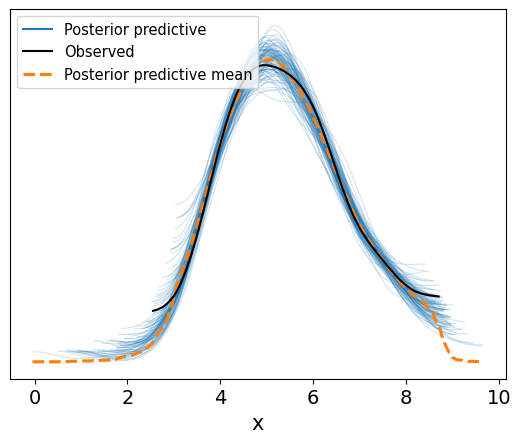

In [22]:
az.plot_ppc(
    task1_idata, 
    # data_pairs={"x": "y_rep"}, # Key = Observed Name, Value = Predictive Name
    num_pp_samples=100
)

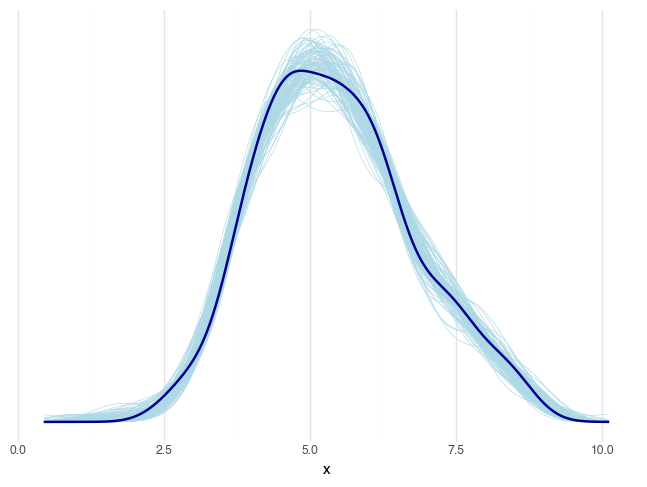

In [23]:
pp_check_dens_overlay(task1_idata, var_name = 'x')

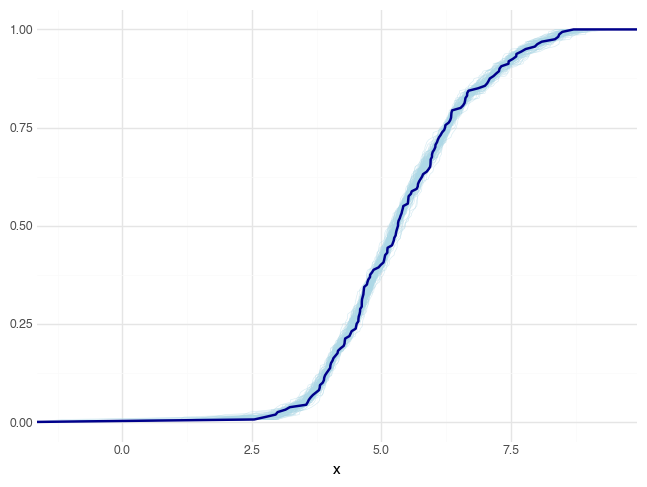

In [24]:
pp_check_ecdf_overlay(task1_idata, var_name = 'x')

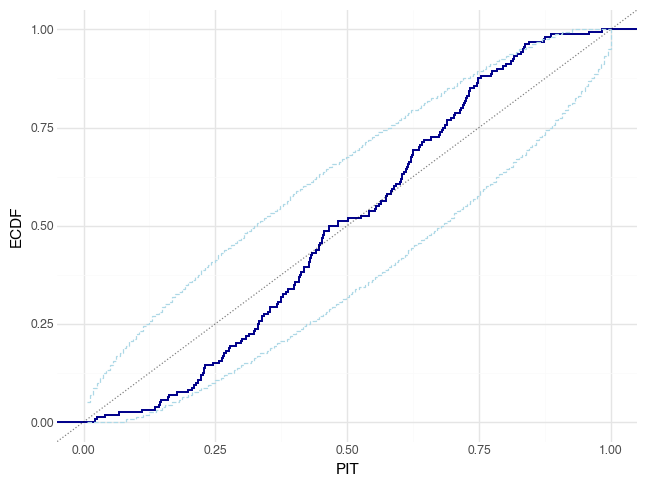

In [25]:
pp_check_pit_ecdf(task1_idata, var_name = 'x')

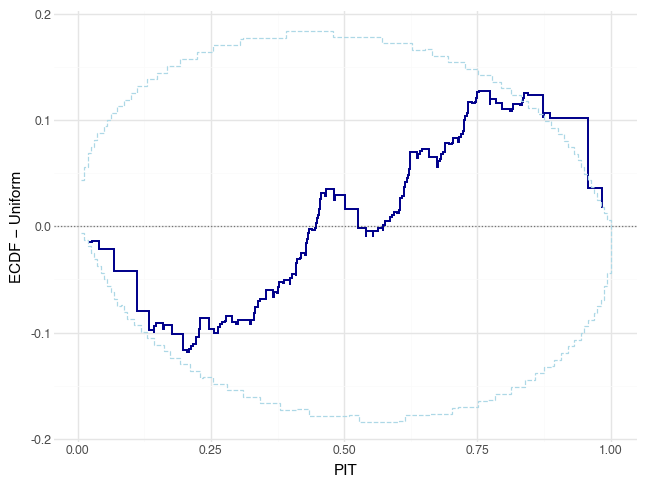

In [26]:
pp_check_pit_ecdf(task1_idata, var_name = 'x', plot_diff=True)

In [27]:
# save inference data 

task1_idata.to_netcdf("../fitted_models/task1.weighted.avg.nc")

'../fitted_models/task1.weighted.avg.nc'

## `task1.weighted.avg.nonc.stan` 

- non-centered parameterization 

In [28]:
task1_mix_stanfile = os.path.join('../stan_files/', "task1.weighted.avg.nonc.stan")
task1_model = CmdStanModel(stan_file=task1_mix_stanfile)

22:14:04 - cmdstanpy - INFO - compiling stan file /Users/shenglong/Downloads/vis-decode-analysis/analysis/stan_files/task1.weighted.avg.nonc.stan to exe file /Users/shenglong/Downloads/vis-decode-analysis/analysis/stan_files/task1.weighted.avg.nonc
22:14:11 - cmdstanpy - INFO - compiled model executable: /Users/shenglong/Downloads/vis-decode-analysis/analysis/stan_files/task1.weighted.avg.nonc


In [29]:
# use shutil to move things around
dest_dir = "../stan_bin_files"
shutil.move(task1_model.exe_file, os.path.join(dest_dir, task1_model.name))
task1_model = CmdStanModel(exe_file=os.path.join(dest_dir, task1_model.name))

In [30]:
# sample 
fit2 = task1_model.sample(
    data = stan_data, 
    chains=4, 
    parallel_chains=4, 
    iter_warmup=4000,
    iter_sampling=4000,
    adapt_delta=0.99, 
    max_treedepth=15,
    show_console=True,
)

22:14:25 - cmdstanpy - INFO - Chain [1] start processing
22:14:25 - cmdstanpy - INFO - Chain [2] start processing
22:14:25 - cmdstanpy - INFO - Chain [3] start processing
22:14:25 - cmdstanpy - INFO - Chain [4] start processing


Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 4000
Chain [1] num_warmup = 4000
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.99
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 15
Chain [1] metric = diag_e (Default)
Chain [1] metric_file =  (Default)
Chain [1] stepsize = 1 (Default)
Chain [1] stepsize_jitter = 0 (Default)
Chain [1] num_chains = 1 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /var/folders/xz/hg6l5mzj2wnb8mr2q4slgnr40000gn/T/tmp70jkojoc/kz9xanl_.json
Chain [1] init = 2 (Default)
Chain [1] random
Chain [1] seed = 76067
C

22:14:46 - cmdstanpy - INFO - Chain [4] done processing


Chain [1] Iteration: 5400 / 8000 [ 67%]  (Sampling)
Chain [4] Iteration: 8000 / 8000 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 12.296 seconds (Warm-up)
Chain [4] 9.318 seconds (Sampling)
Chain [4] 21.614 seconds (Total)
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [3] Iteration: 7400 / 8000 [ 92%]  (Sampling)
Chain [2] Iteration: 7900 / 8000 [ 98%]  (Sampling)


22:14:47 - cmdstanpy - INFO - Chain [2] done processing


Chain [3] Iteration: 7500 / 8000 [ 93%]  (Sampling)
Chain [2] Iteration: 8000 / 8000 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 11.611 seconds (Warm-up)
Chain [2] 10.459 seconds (Sampling)
Chain [2] 22.07 seconds (Total)
Chain [2] 
Chain [2] 
Chain [1] Iteration: 5500 / 8000 [ 68%]  (Sampling)
Chain [3] Iteration: 7600 / 8000 [ 95%]  (Sampling)
Chain [1] Iteration: 5600 / 8000 [ 70%]  (Sampling)
Chain [3] Iteration: 7700 / 8000 [ 96%]  (Sampling)
Chain [3] Iteration: 7800 / 8000 [ 97%]  (Sampling)
Chain [1] Iteration: 5700 / 8000 [ 71%]  (Sampling)
Chain [3] Iteration: 7900 / 8000 [ 98%]  (Sampling)


22:14:48 - cmdstanpy - INFO - Chain [3] done processing


Chain [3] Iteration: 8000 / 8000 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 12.967 seconds (Warm-up)
Chain [3] 10.24 seconds (Sampling)
Chain [3] 23.207 seconds (Total)
Chain [3] 
Chain [3] 
Chain [1] Iteration: 5800 / 8000 [ 72%]  (Sampling)
Chain [1] Iteration: 5900 / 8000 [ 73%]  (Sampling)
Chain [1] Iteration: 6000 / 8000 [ 75%]  (Sampling)
Chain [1] Iteration: 6100 / 8000 [ 76%]  (Sampling)
Chain [1] Iteration: 6200 / 8000 [ 77%]  (Sampling)
Chain [1] Iteration: 6300 / 8000 [ 78%]  (Sampling)
Chain [1] Iteration: 6400 / 8000 [ 80%]  (Sampling)
Chain [1] Iteration: 6500 / 8000 [ 81%]  (Sampling)
Chain [1] Iteration: 6600 / 8000 [ 82%]  (Sampling)
Chain [1] Iteration: 6700 / 8000 [ 83%]  (Sampling)
Chain [1] Iteration: 6800 / 8000 [ 85%]  (Sampling)
Chain [1] Iteration: 6900 / 8000 [ 86%]  (Sampling)
Chain [1] Iteration: 7000 / 8000 [ 87%]  (Sampling)
Chain [1] Iteration: 7100 / 8000 [ 88%]  (Sampling)
Chain [1] Iteration: 7200 / 8000 [ 90%]  (Sampling)
Chain [1] Iteratio

22:14:56 - cmdstanpy - INFO - Chain [1] done processing
22:14:56 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: task1x46weightedx46avgx46nonc_model_namespace::log_prob: theta[1] is nan, but must be greater than or equal to 0.000000 (in 'task1.weighted.avg.nonc.stan', line 42, column 2 to column 36)
	Exception: task1x46weightedx46avgx46nonc_model_namespace::log_prob: theta[1] is nan, but must be greater than or equal to 0.000000 (in 'task1.weighted.avg.nonc.stan', line 42, column 2 to column 36)
	Exception: task1x46weightedx46avgx46nonc_model_namespace::log_prob: theta[1] is nan, but must be greater than or equal to 0.000000 (in 'task1.weighted.avg.nonc.stan', line 42, column 2 to column 36)
	Exception: normal_lpdf: Scale parameter is nan, but must be positive! (in 'task1.weighted.avg.nonc.stan', line 75, column 4 to line 76, column 126)
	Exception: normal_lpdf: Scale parameter is nan, but must be positive! (in 'task1.weighted.avg.nonc.stan', line 75, column 4 to li

Chain [1] Iteration: 8000 / 8000 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 15.685 seconds (Warm-up)
Chain [1] 15.98 seconds (Sampling)
Chain [1] 31.665 seconds (Total)
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 


In [31]:
fit2.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,2.875580,0.150707,7.971720e+00,7.994890,-10.929900,3.274940,15.224400,2844.00,5519.42,61.8300,1.00097
mu_mod_mean,0.005171,0.000143,1.786340e-02,0.017680,-0.023731,0.005104,0.034812,15589.00,12836.70,338.9130,1.00004
mu_mod_sd,0.047938,0.000270,2.415670e-02,0.025597,0.009436,0.047231,0.088883,7172.32,5766.27,155.9300,1.00032
mu_med_mean,0.052535,0.000801,5.142960e-02,0.050246,-0.028908,0.051225,0.138892,4119.64,9612.66,89.5632,1.00104
mu_med_sd,0.126185,0.001043,5.215930e-02,0.044436,0.037984,0.124510,0.214595,2380.34,2295.24,51.7500,1.00105
...,...,...,...,...,...,...,...,...,...,...,...
x_org[156],7.271870,NaN,5.355880e-13,0.000000,7.271870,7.271870,7.271870,NaN,NaN,NaN,NaN
x_org[157],7.607780,NaN,3.819290e-13,0.000000,7.607780,7.607780,7.607780,NaN,NaN,NaN,NaN
x_org[158],7.457210,NaN,5.533520e-13,0.000000,7.457210,7.457210,7.457210,NaN,NaN,NaN,NaN
x_org[159],6.622870,NaN,5.675640e-13,0.000000,6.622870,6.622870,6.622870,NaN,NaN,NaN,NaN


In [32]:
# Translate to InferenceData 

task1_idata = az.from_cmdstanpy(
    posterior=fit2, 
    posterior_predictive=["y_rep"], 
    observed_data={"x": stan_data["x"]}
)
# rename things 
task1_idata.posterior_predictive = task1_idata.posterior_predictive.rename({"y_rep": "x"})
task1_idata

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> observed_data

In [18]:
az.summary(task1_idata, filter_vars='regex', var_names=["~x\_org", "~y\_rep"])

<positron-console-cell-18>:1: SyntaxWarning: invalid escape sequence '\_'
<positron-console-cell-18>:1: SyntaxWarning: invalid escape sequence '\_'


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_mod_mean,0.005,0.018,-0.027,0.040,0.000,0.000,19105.0,11916.0,1.0
mu_mod_sd,0.048,0.024,0.002,0.088,0.000,0.000,6933.0,4878.0,1.0
mu_med_mean,0.051,0.053,-0.047,0.150,0.001,0.000,3893.0,7294.0,1.0
mu_med_sd,0.125,0.053,0.009,0.214,0.001,0.001,2402.0,2405.0,1.0
log_sigma_mod_mean,-1.495,0.094,-1.672,-1.320,0.001,0.001,17685.0,12890.0,1.0
...,...,...,...,...,...,...,...,...,...
inv_mse_mod[155],1.068,0.149,0.822,1.373,0.001,0.001,13859.0,12927.0,1.0
inv_mse_mod[156],1.138,0.165,0.868,1.477,0.001,0.002,13831.0,12926.0,1.0
inv_mse_mod[157],36.255,31.089,1.939,85.118,0.272,0.694,13182.0,11566.0,1.0
inv_mse_mod[158],1.327,0.210,0.979,1.753,0.002,0.002,13760.0,12817.0,1.0


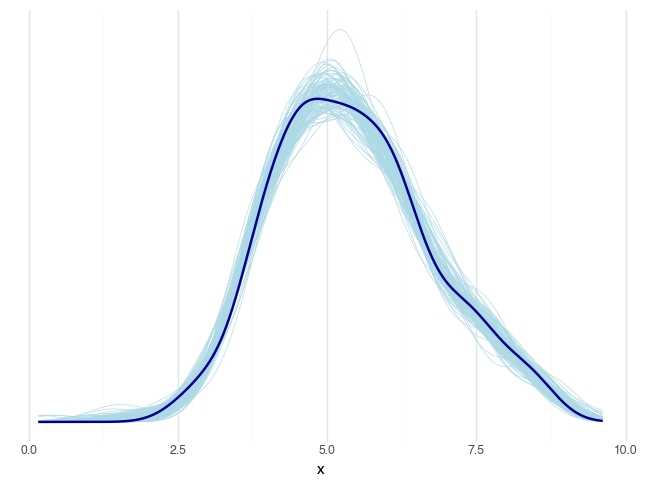

In [34]:
pp_check_dens_overlay(task1_idata, var_name='x')

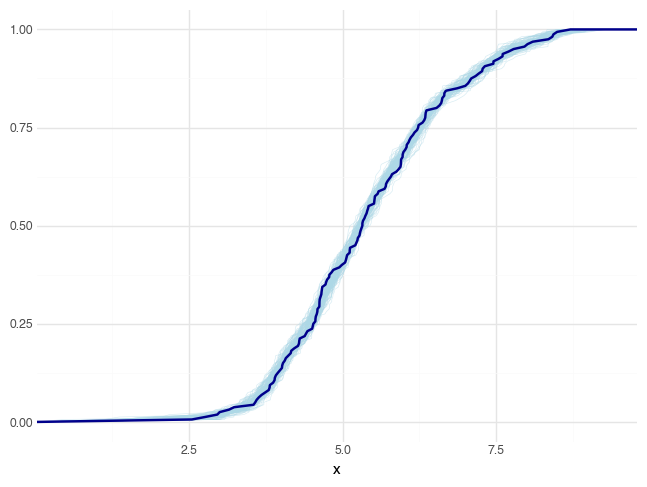

In [35]:
pp_check_ecdf_overlay(task1_idata, var_name='x')

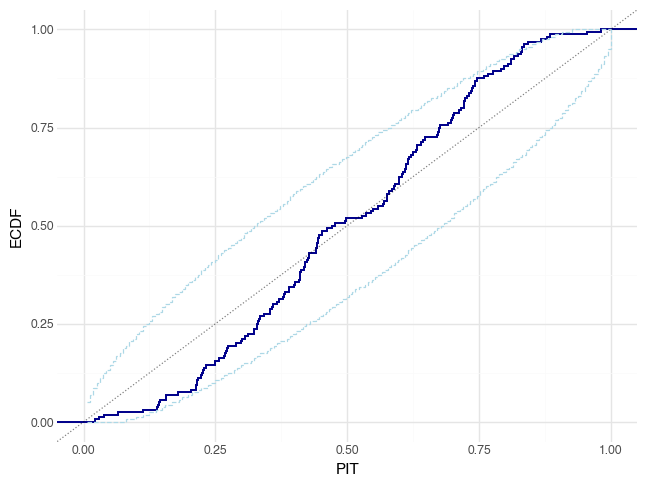

In [36]:
pp_check_pit_ecdf(task1_idata, var_name='x')

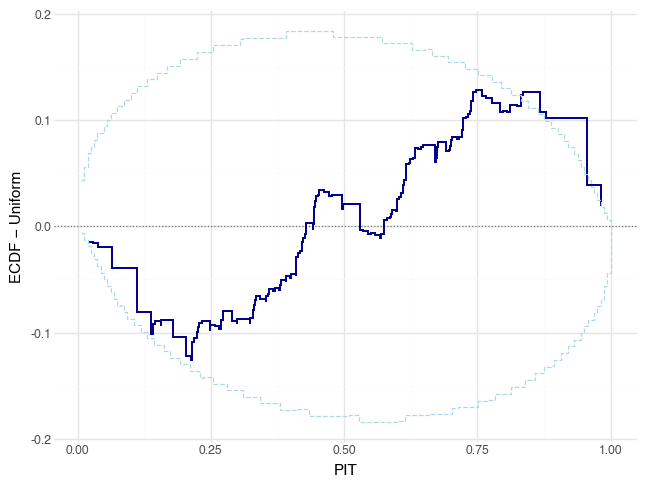

In [37]:
pp_check_pit_ecdf(task1_idata, var_name='x', plot_diff=True)

In [38]:
# save inferenceData object 
task1_idata.to_netcdf("../fitted_models/task1.weighted.avg.nonc.nc")

'../fitted_models/task1.weighted.avg.nonc.nc'

In [ ]:
# TODO: get the posterior 

## `task1.weighted.avg.nonc.normal.stan` 

In [39]:
task1_mix_stanfile = os.path.join('../stan_files/', "task1.weighted.avg.nonc.normal.stan")
task1_model = CmdStanModel(stan_file=task1_mix_stanfile)

22:17:27 - cmdstanpy - INFO - compiling stan file /Users/shenglong/Downloads/vis-decode-analysis/analysis/stan_files/task1.weighted.avg.nonc.normal.stan to exe file /Users/shenglong/Downloads/vis-decode-analysis/analysis/stan_files/task1.weighted.avg.nonc.normal
22:17:33 - cmdstanpy - INFO - compiled model executable: /Users/shenglong/Downloads/vis-decode-analysis/analysis/stan_files/task1.weighted.avg.nonc.normal


In [40]:
# use shutil to move executable to untracked folder around
dest_dir = "../stan_bin_files"
shutil.move(task1_model.exe_file, os.path.join(dest_dir, task1_model.name))
task1_model = CmdStanModel(exe_file=os.path.join(dest_dir, task1_model.name))

In [41]:
# sample 
fit3 = task1_model.sample(
    data = stan_data, 
    chains=4, 
    parallel_chains=4, 
    iter_warmup=4000,
    iter_sampling=4000,
    adapt_delta=0.99, 
    max_treedepth=15,
    show_console=True,
)

22:17:44 - cmdstanpy - INFO - Chain [1] start processing
22:17:44 - cmdstanpy - INFO - Chain [2] start processing
22:17:44 - cmdstanpy - INFO - Chain [3] start processing
22:17:44 - cmdstanpy - INFO - Chain [4] start processing


Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 4000
Chain [1] num_warmup = 4000
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.99
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 15
Chain [1] metric = diag_e (Default)
Chain [1] metric_file =  (Default)
Chain [1] stepsize = 1 (Default)
Chain [1] stepsize_jitter = 0 (Default)
Chain [1] num_chains = 1 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /var/folders/xz/hg6l5mzj2wnb8mr2q4slgnr40000gn/T/tmp70jkojoc/xvxcen4j.json
Chain [1] init = 2 (Default)
Chain [1] random
Chain [1] seed = 2577
Ch

22:24:47 - cmdstanpy - INFO - Chain [4] done processing


Chain [4] Iteration: 8000 / 8000 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 267.913 seconds (Warm-up)
Chain [4] 154.827 seconds (Sampling)
Chain [4] 422.74 seconds (Total)
Chain [4] 
Chain [4] 
Chain [3] Iteration: 4300 / 8000 [ 53%]  (Sampling)
Chain [1] Iteration: 4600 / 8000 [ 57%]  (Sampling)
Chain [1] Iteration: 4700 / 8000 [ 58%]  (Sampling)
Chain [2] Iteration: 4100 / 8000 [ 51%]  (Sampling)
Chain [3] Iteration: 4400 / 8000 [ 55%]  (Sampling)
Chain [1] Iteration: 4800 / 8000 [ 60%]  (Sampling)
Chain [1] Iteration: 4900 / 8000 [ 61%]  (Sampling)
Chain [1] Iteration: 5000 / 8000 [ 62%]  (Sampling)
Chain [3] Iteration: 4500 / 8000 [ 56%]  (Sampling)
Chain [1] Iteration: 5100 / 8000 [ 63%]  (Sampling)
Chain [2] Iteration: 4200 / 8000 [ 52%]  (Sampling)
Chain [1] Iteration: 5200 / 8000 [ 65%]  (Sampling)
Chain [3] Iteration: 4600 / 8000 [ 57%]  (Sampling)
Chain [1] Iteration: 5300 / 8000 [ 66%]  (Sampling)
Chain [1] Iteration: 5400 / 8000 [ 67%]  (Sampling)
Chain [3] Itera

22:28:19 - cmdstanpy - INFO - Chain [1] done processing


...

22:32:33 - cmdstanpy - INFO - Chain [3] done processing


Chain [3] Iteration: 8000 / 8000 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 381.255 seconds (Warm-up)
Chain [3] 507.867 seconds (Sampling)
Chain [3] 889.122 seconds (Total)
Chain [3] 
Chain [3] 
Chain [3] 
Chain [2] Iteration: 6000 / 8000 [ 75%]  (Sampling)
Chain [2] Iteration: 6100 / 8000 [ 76%]  (Sampling)
Chain [2] Iteration: 6200 / 8000 [ 77%]  (Sampling)
Chain [2] Iteration: 6300 / 8000 [ 78%]  (Sampling)
Chain [2] Iteration: 6400 / 8000 [ 80%]  (Sampling)
Chain [2] Iteration: 6500 / 8000 [ 81%]  (Sampling)
Chain [2] Iteration: 6600 / 8000 [ 82%]  (Sampling)
Chain [2] Iteration: 6700 / 8000 [ 83%]  (Sampling)
Chain [2] Iteration: 6800 / 8000 [ 85%]  (Sampling)
Chain [2] Iteration: 6900 / 8000 [ 86%]  (Sampling)
Chain [2] Iteration: 7000 / 8000 [ 87%]  (Sampling)
Chain [2] Iteration: 7100 / 8000 [ 88%]  (Sampling)
Chain [2] Iteration: 7200 / 8000 [ 90%]  (Sampling)
Chain [2] Iteration: 7300 / 8000 [ 91%]  (Sampling)
Chain [2] Iteration: 7400 / 8000 [ 92%]  (Sampling)
Cha

22:41:25 - cmdstanpy - INFO - Chain [2] done processing
22:41:25 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: task1x46weightedx46avgx46noncx46normal_model_namespace::log_prob: theta[1] is nan, but must be greater than or equal to 0.000000 (in 'task1.weighted.avg.nonc.normal.stan', line 42, column 2 to column 36)
	Exception: task1x46weightedx46avgx46noncx46normal_model_namespace::log_prob: theta[1] is nan, but must be greater than or equal to 0.000000 (in 'task1.weighted.avg.nonc.normal.stan', line 42, column 2 to column 36)
	Exception: normal_lpdf: Scale parameter is nan, but must be positive! (in 'task1.weighted.avg.nonc.normal.stan', line 75, column 4 to line 76, column 126)
	Exception: normal_lpdf: Scale parameter is nan, but must be positive! (in 'task1.weighted.avg.nonc.normal.stan', line 75, column 4 to line 76, column 126)
	Exception: task1x46weightedx46avgx46noncx46normal_model_namespace::log_prob: theta[1] is nan, but must be greater than or equal to 0.0

Chain [2] 
Chain [2] Elapsed Time: 411.721 seconds (Warm-up)
Chain [2] 1008.89 seconds (Sampling)
Chain [2] 1420.61 seconds (Total)
Chain [2] 
Chain [2] 
Chain [2] 


22:41:26 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 29 divergent transitions (0.7%)
	Chain 2 had 12 divergent transitions (0.3%)
	Chain 3 had 11 divergent transitions (0.3%)
	Chain 4 had 23 divergent transitions (0.6%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


In [ ]:
# check the paired plots to see where the funnel is happening ... 
# Michael Betancourt 

# Translate to InferenceData 

task1_idata = az.from_cmdstanpy(
    posterior=fit3, 
    posterior_predictive=["y_rep"], 
    observed_data={"x": stan_data["x"]}
)
# rename things 
task1_idata.posterior_predictive = task1_idata.posterior_predictive.rename({"y_rep": "x"})
task1_idata

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> observed_data

In [24]:
az.summary(task1_idata)

/Users/shenglong/Downloads/vis-decode-analysis/.venv/lib/python3.13/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/shenglong/Downloads/vis-decode-analysis/.venv/lib/python3.13/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_mod_mean,-0.003,0.035,-0.066,0.064,0.001,0.000,3329.0,5764.0,1.0
mu_mod_sd,0.090,0.031,0.037,0.148,0.001,0.001,2733.0,4177.0,1.0
mu_med_mean,0.054,0.050,-0.038,0.149,0.001,0.000,4098.0,7762.0,1.0
mu_med_sd,0.125,0.049,0.030,0.220,0.001,0.001,2244.0,1817.0,1.0
log_sigma_mod_mean,-3.058,0.564,-4.173,-2.031,0.008,0.005,4606.0,7347.0,1.0
...,...,...,...,...,...,...,...,...,...
x_org[155],7.272,0.000,7.272,7.272,0.000,0.000,16000.0,16000.0,NaN
x_org[156],7.608,0.000,7.608,7.608,0.000,0.000,16000.0,16000.0,NaN
x_org[157],7.457,0.000,7.457,7.457,0.000,0.000,16000.0,16000.0,NaN
x_org[158],6.623,0.000,6.623,6.623,0.000,0.000,16000.0,16000.0,NaN


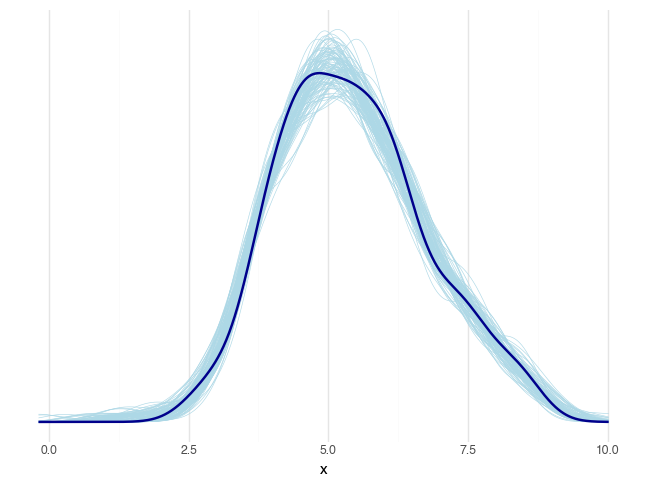

In [44]:
pp_check_dens_overlay(task1_idata, var_name='x')

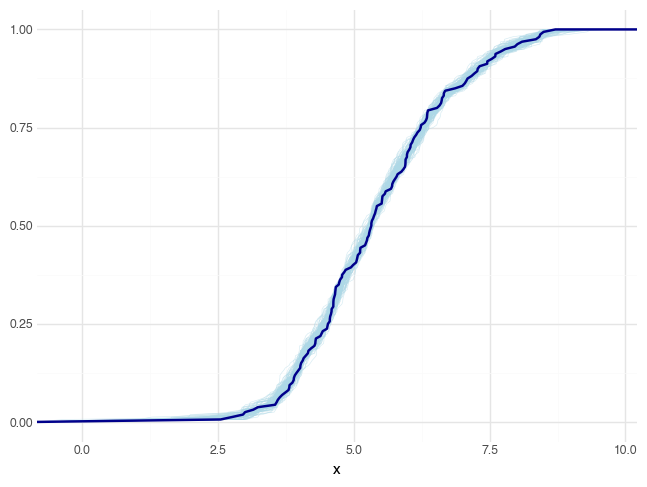

In [45]:
pp_check_ecdf_overlay(task1_idata, var_name='x')

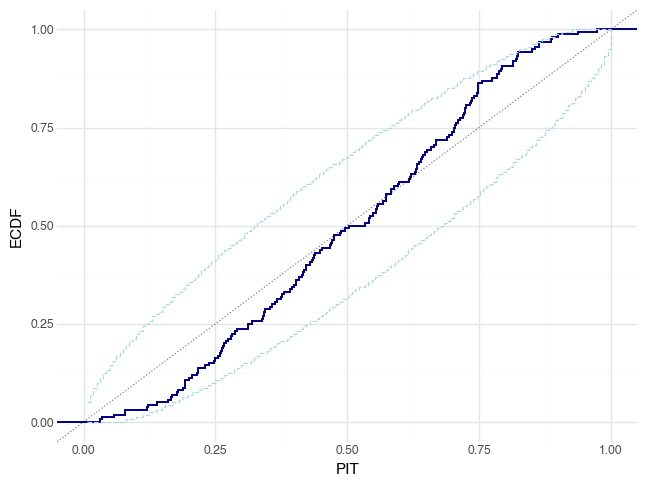

In [46]:
pp_check_pit_ecdf(task1_idata, var_name='x')

In [47]:
# TODO 
# get the grouped function to work ... becasue this overall isn't quite informative 
# also still has divergent transitions ... WHY??? 

In [48]:
# save inferenceData object 
task1_idata.to_netcdf("../fitted_models/task1.weighted.avg.nonc.normal.nc")

'../fitted_models/task1.weighted.avg.nonc.normal.nc'

---

## `task1.mix.stan` 

--- hmm apparently this one doesn't compile because the original definition is a bit wrong ...??? 



In [ ]:
# task1_mix_stanfile = os.path.join('../stan_files/', "task1.weighted.avg.nonc.normal.stan")
# task1_model = CmdStanModel(stan_file=task1_mix_stanfile)

15:02:34 - cmdstanpy - INFO - compiling stan file /Users/shenglong/Downloads/vis-decode-analysis/analysis/stan_files/task1.weighted.avg.nonc.normal.stan to exe file /Users/shenglong/Downloads/vis-decode-analysis/analysis/stan_files/task1.weighted.avg.nonc.normal
15:02:40 - cmdstanpy - INFO - compiled model executable: /Users/shenglong/Downloads/vis-decode-analysis/analysis/stan_files/task1.weighted.avg.nonc.normal
